In [1]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import os
#os.chdir(r"E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


### 1. DATA preprocessing

### 1.1 Change the start data and end data column of metadata file based on streamflow timeseries (initial it was based on stream level)   

In [2]:
gauge_info=pd.read_csv(r"3_Data\Data_r\2_Station\metadata.csv")
gauge_info.drop(columns=['Level_Entries'],inplace=True)


for g,stn in enumerate(gauge_info['GaugeID'].values):
    data1=pd.read_csv(f'3_Data/Data_r/2_Station/{stn}.csv',index_col=0,parse_dates=True)  
    data1.index=pd.DatetimeIndex(data1.index)      
    data1.drop(columns=['Level (m)'],inplace=True)
    data1=data1[data1['Streamflow (cumecs)'].notna()]


    if(len(data1)!=0):
        gauge_info.loc[g,['Start_date']]=data1.index[0].strftime("%Y-%m-%d")
        gauge_info.loc[g,['End_date']]=data1.index[-1].strftime("%Y-%m-%d")
        gauge_info.loc[g,['Expected_entries']]=len(pd.date_range(data1.index[0],data1.index[-1]))
        
        data1=data1.resample('D').asfreq()  # Adding full strech of dates by giving nan values where there is no dates
        data1.to_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv') 

    else:
        gauge_info=gauge_info.drop(g)
 
gauge_info['missing_percent']=(1-(gauge_info['Streamflow_Entries']/gauge_info['Expected_entries']))*100     
gauge_info.to_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv')  
    

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_12436\1699275900.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data1=pd.read_csv(f'3_Data/Data_r/2_Station/{stn}.csv',index_col=0,parse_dates=True)
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_12436\1699275900.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data1=pd.read_csv(f'3_Data/Data_r/2_Station/{stn}.csv',index_col=0,parse_dates=True)


## 2. station subsetting
 1. Identify the stations with minimum 30 years of data
 2. Subset the station with minimum 30 years of data and with period upto 2010
 3. Percentage of missing data

### 2.1 Full stations

,GaugeID,Station,Latitude,Longitude,River Name/ Tributory/ SubTributory,Basin,State,Start_date,End_date,Streamflow_Entries,Privacy,Expected_entries,missing_percent
0,IWM-gauge-1,Thotapalli,18.7800,83.5000,NaN,East flowing rivers between mahanadi and pennar,Andhra Pradesh,1999-08-01,2015-07-07,5727,Open,5820.0,1.597938
2,IWM-gauge-3,Kattaleru @ tiruvuru,17.0900,80.6200,NaN,Krishna,Andhra Pradesh,1999-07-28,2014-11-06,1216,Open,5581.0,78.211790
3,IWM-gauge-4,Nandipalli,14.7211,79.0189,Pennar/Sagaileru,Pennar,Andhra Pradesh,1990-06-01,2018-11-12,9712,Open,10392.0,6.543495
4,IWM-gauge-5,Paradespalem,17.8500,83.3600,NaN,East flowing rivers between mahanadi and pennar,Andhra Pradesh,1999-10-01,2005-12-03,404,Open,2256.0,82.092199
6,IWM-gauge-7,Pillaperu riverr @ narravada.,14.9300,79.4200,NaN,East flowing rivers between mahanadi and pennar,Andhra Pradesh,2000-08-31,2018-07-08,877,Open,6521.0,86.551142
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,IWM-gauge-1081,Fekoghat,22.3086,86.9164,Subarnarekha/Dul ung,Subarnarekha,West Bengal,1988-06-18,2018-10-31,4000,Open,11093.0,63.941224
1081,IWM-gauge-1082,Gopiballavpur,22.2200,86.9000,Subarnarekha,Subernarekha,West Bengal,2015-06-04,2019-03-06,1372,Open,1372.0,0.000000
1101,IWM-gauge-1102,Domohani,26.5628,88.7583,Brahmaputra/ Teesta,Ganga - Brahmaputra -Meghna/Barak,West Bengal,2000-01-06,2021-05-31,7628,Restricted,7817.0,2.417807
1102,IWM-gauge-1103,Hasimara,26.7292,89.3236,Brahmaputra/ Torsa,Ganga - Brahmaputra -Meghna/Barak,West Bengal,1990-01-06,2021-05-31,11296,Restricted,11469.0,1.508414


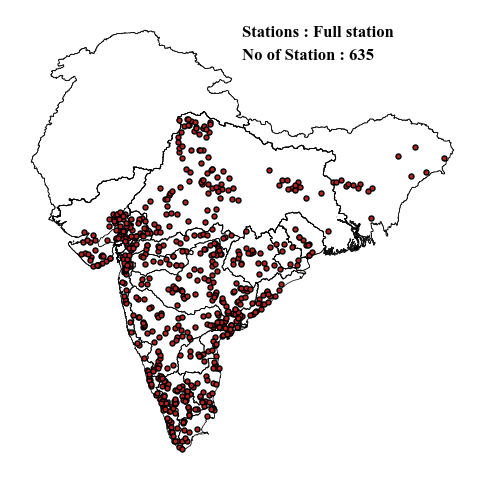

In [7]:
#gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
Station_Map(gauge_info,'Full station')
gauge_info

### 2.2 Minimum 30 year data

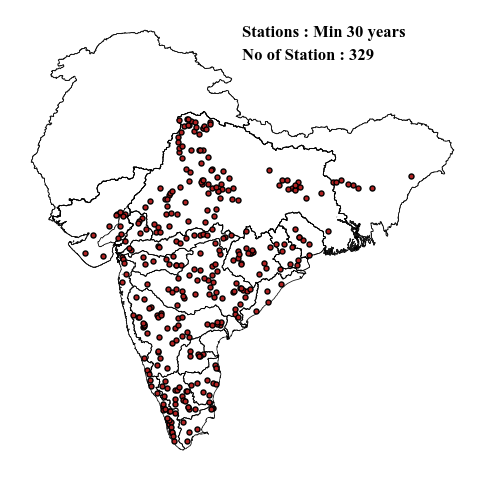

In [10]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")

gauge_info['Period_length']=gauge_info['Expected_entries']/365


## Minimum 30 years
Min30=gauge_info.loc[gauge_info['Period_length']>20]
Station_Map(Min30,'Min 30 years')


## Minimum 30 years till 2018
#Min30_2017=Min30.loc[(pd.to_datetime(Min30['End_date'])>'2017')]
#Station_Map(Min30_2017,'Min 30 years (till 2017)')

# ## Minimum 30 years till 2015
# Min30_2015=Min30.loc[(pd.to_datetime(Min30['End_date'])>'2015')]
# Station_Map(Min30_2015,'Min 30 years (till 2015)')

# ## Minimum 30 years till 2010
# Min30_2011=Min30.loc[(pd.to_datetime(Min30['End_date'])>'2011')]
# Station_Map(Min30_2011,'Min 30 years (till 2011)')

# ## Minimum 30 years till 2005
# Min30_2005=Min30.loc[(pd.to_datetime(Min30['End_date'])>'2005')]
# Station_Map(Min30_2005,'Min 30 years (till 2005)')



### 2.3 Minimum 30 years of data without gaps

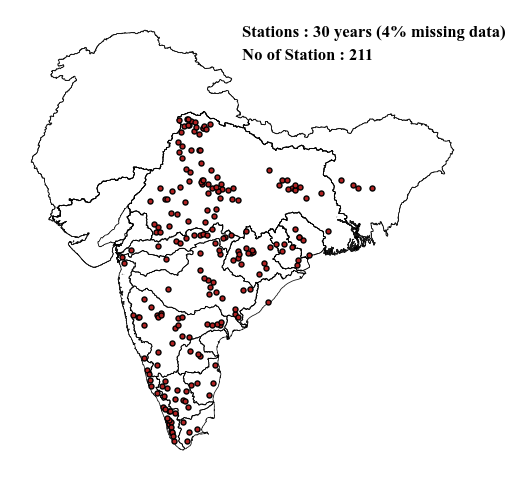

In [27]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")

gauge_info['Period_length']=gauge_info['Expected_entries']/365
gaps=gauge_info['Streamflow_Entries']/gauge_info['Expected_entries']


### 90% data
prcnt=96
gauge_new=gauge_info.loc[(gauge_info['Period_length']>22) & (gaps>prcnt/100)]
Station_Map(gauge_new,f'30 years ({100-prcnt}% missing data)')




### 2.4 Type of gaps  
Here we are checking if there is big gaps in data across years, or in between months and so and so




In [11]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final criteria
yr_strt=1985;yr_end=2012
period=yr_end-yr_strt;miss_prc=8
gauge_new=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_new.reset_index(drop=True,inplace=True)


#1 checking if a data is completely missing on years

stn=gauge_info['GaugeID'].values[35]
for g,stn in enumerate(gauge_new['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True) 
    nan_years = data1.groupby(data1.index.year)['Streamflow (cumecs)'].apply(lambda x: x.isna().all())
   
    yrs=nan_years[nan_years].index.to_list()
    gauge_new.loc[g,'nan_years']=np.array(yrs).shape[0]
    

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_13212\276335507.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gauge_new.loc[g,'nan_years']=np.array(yrs).shape[0]


Unnamed: 0                                       139
GaugeID                                IWM-gauge-140
Station                                       Rampur
Latitude                                     21.6517
Longitude                                    82.5172
River Name/ Tributory/ SubTributory    Mahanadi/Jonk
Basin                                       Mahanadi
State                                   Chhattisgarh
Start_date                                1971-02-20
End_date                                  2019-03-07
Streamflow_Entries                             16286
Privacy                                         Open
Expected_entries                             17548.0
missing_percent                             7.191703
Period_length                              48.076712
Name: 35, dtype: object

## 3 INTERPOLATION

In [32]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final criteria
yr_strt=1985;yr_end=2012
period=yr_end-yr_strt; miss_prc=8
gauge_final=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_final.reset_index(drop=True,inplace=True)

stn=gauge_final['GaugeID'].values[35]

for g,stn in enumerate(gauge_new['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True) 
    nan_years = data1.groupby(data1.index.year)['Streamflow (cumecs)'].apply(lambda x: x.isna().all())
    nan_years=nan_years[nan_years].index.to_list()
    data1=data1.interpolate(method='linear')
    data1.to_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv') 
    



## 3. Create streamflow data over different stations into single xarrayy (station and time)
The main aim is to make a consistent single xarray for better management

In [2]:
gauge_info_p=pd.read_csv(f'3_Data/Data_p/2_Station/gauge_info_p.csv',index_col=0)
date1=pd.date_range(start='1970',end='2021',freq='D')
station=list(gauge_info_p['Station'])
gauge_final=pd.DataFrame(index=date1, columns=station)

for g in range(len(gauge_info_p.index)):
    gauge_id=pd.read_csv(f'3_Data/Data_p/2_Station/streamflow_data/{gauge_info_p.iloc[g,0]}.csv',index_col=0,parse_dates=True)
    common_date=np.intersect1d(gauge_id.index,date1)
    gauge_final.loc[common_date,gauge_info_p.iloc[g,1]]=gauge_id.loc[common_date, 'Streamflow (cumecs)']

gauge_xr=xr.DataArray(np.array(gauge_final),coords=[date1,station],dims=['time','station'],name='streamflow')
gauge_xr = xr.Dataset({'streamflow': gauge_xr })
gauge_xr.to_netcdf(f'3_Data/Data_p/2_Station/Gauge_streamflow.nc')   

# FUNCTIONS

### 1. Station visualization

In [6]:

def Station_Map(data,condition):

    #data=pd.read_csv(r"3_Data\Data_p\2_Station\1_Streamflow_data\data.csv")
    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')
 
    fig, ax1 = plt.subplots(1, 1, figsize=(6,6), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]

    c1=np.repeat(['Blue'],len(data['Latitude']))
    sc=ax1.scatter(data['Longitude'],data['Latitude'],c='firebrick',s=13,edgecolor='black')

    ax1.text(0.50, 0.95, f'Stations : {condition}', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    ax1.text(0.5, 0.9, f'No of Station : {len(data)}' , fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    plt.savefig(fr'2_Analysis\0_Datapreprocessing\Outputs\{condition}', bbox_inches='tight',dpi=1000)
